In [ ]:
import mlflow
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression

# Start an MLflow run
with mlflow.start_run():
    # Create and train a model
    X, y = make_regression(n_features=4, n_informative=2, random_state=0)
    model = RandomForestRegressor(max_depth=2, random_state=0)
    model.fit(X, y)

    # Log the model and its artifacts
    mlflow.sklearn.log_model(
        sk_model=model,
        artifact_path="random-forest-model",
        registered_model_name="RandomForestModel"
    )

    # Note the model URI to use in the next step
    # Example: "runs:/<run_id>/random-forest-model"

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hassan06/nslkdd")

print("Path to dataset files:", path)

100%|██████████| 13.9M/13.9M [00:00<00:00, 29.0MB/s]

Extracting files...


Path to dataset files: C:\Users\mamma\.cache\kagglehub\datasets\hassan06\nslkdd\versions\1


# intrusion detection 

In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, TargetEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## EDA

In [3]:
col_names = ["duration", "protocol_type", "service", "flag", "src_bytes",
             "dst_bytes", "land", "wrong_fragment", "urgent", "hot", "num_failed_logins",
             "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root",
             "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds",
             "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate",
             "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
             "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
             "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
             "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
             "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "attack", "level"]

In [ ]:
train_df = pd.read_csv("NSL-KDD Dataset/KDDTrain+.txt", header=None, names=col_names)
test_df = pd.read_csv("NSL-KDD Dataset/KDDTest+.txt", header=None, names=col_names)
train_df['attack_type'] = train_df['attack'].apply(lambda x:'normal' if x=='normal' else 'attack')
test_df['attack_type'] = test_df['attack'].apply(lambda r: 'normal' if r == 'normal' else 'attack')

<Axes: xlabel='attack'>

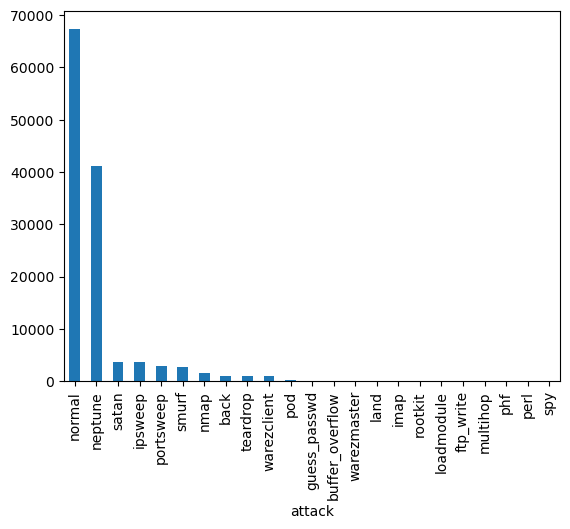

In [16]:
train_df['attack'].value_counts().plot.bar()

In [14]:
train_df['attack_type'].value_counts()

attack_type
normal    67343
attack    58630
Name: count, dtype: int64

In [ ]:
categorical_cols = ['protocol_type', 'service', 'flag']
numerical_cols = list(set(train_df.columns) - set(categorical_cols) - set(['attack', 'level', 'attack_type']))

In [21]:
train_df.select_dtypes("object").columns

Index(['protocol_type', 'service', 'flag', 'attack', 'attack_type'], dtype='object')

In [22]:
train_df.select_dtypes("number").columns

Index(['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
       'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
       'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
       'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'level'],
      dtype='object')

## FE

In [23]:
categorical_cols = ['protocol_type', 'service', 'flag']
numerical_cols = list(set(train_df.columns) - set(categorical_cols) - set(['attack', 'level', 'attack_type']))

In [31]:
train_df[categorical_cols].nunique()

protocol_type     3
service          70
flag             11
dtype: int64

In [33]:
train_df_processed = pd.get_dummies(train_df, columns=categorical_cols, drop_first=True)
test_df_processed = pd.get_dummies(test_df, columns=categorical_cols, drop_first=True)

In [34]:
train_labels = train_df_processed['attack_type']
test_labels = test_df_processed['attack_type']
train_features = train_df_processed.drop(columns=['attack', 'level', 'attack_type'])
test_features = test_df_processed.drop(columns=['attack', 'level', 'attack_type'])

In [35]:
common_cols = list(set(train_features.columns) & set(test_features.columns))
train_features = train_features[common_cols]
test_features = test_features[common_cols]

In [36]:
le = LabelEncoder()
y_train = le.fit_transform(train_labels)
y_test = le.transform(test_labels)

## Train

In [45]:
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(train_features, y_train)
y_pred = model.predict(test_features)
y_score = model.predict_proba(test_features)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy:{accuracy}")

Accuracy:0.7782558552164656


In [39]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['attack', 'normal']))


Classification Report:
              precision    recall  f1-score   support

      attack       0.97      0.63      0.76     12833
      normal       0.67      0.97      0.79      9711

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.78     22544
weighted avg       0.84      0.78      0.78     22544




Confusion Matrix:


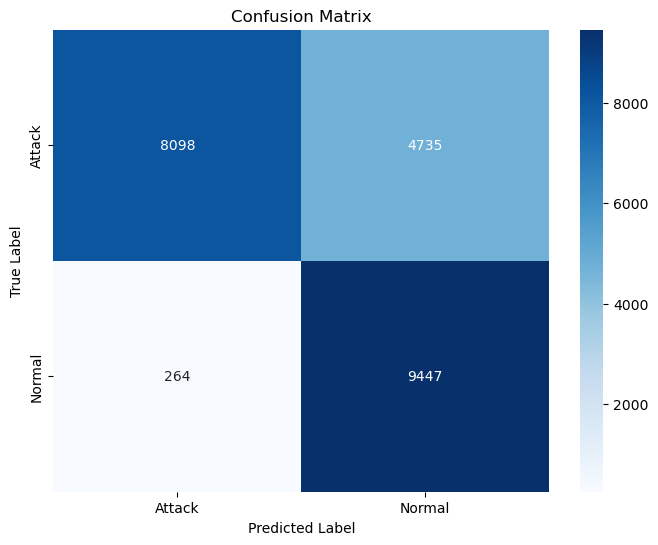

In [40]:
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Attack', 'Normal'], yticklabels=['Attack', 'Normal'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Top 10 Most Important Features:


C:\Users\mamma\AppData\Local\Temp\ipykernel_30472\1053930683.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df.head(15), palette='rocket')


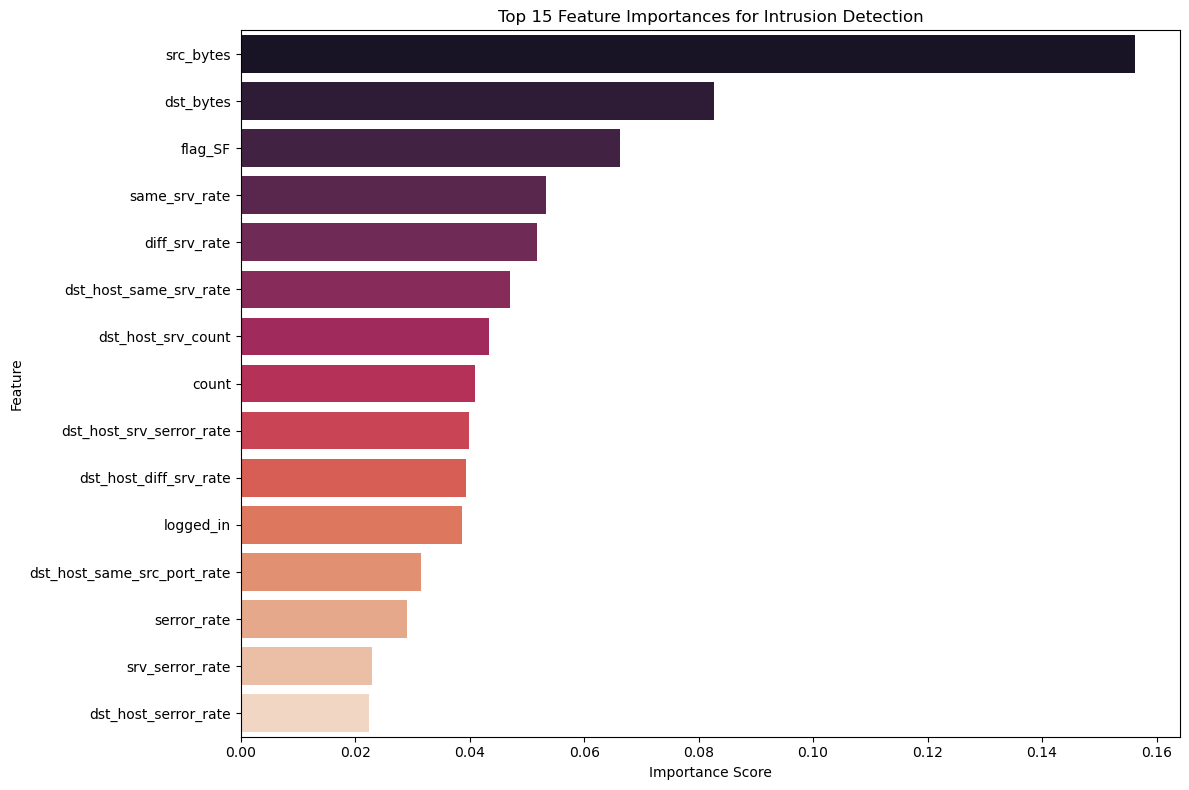

In [46]:
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': train_features.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)
print("Top 10 Most Important Features:")
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(15), palette='rocket')
plt.title('Top 15 Feature Importances for Intrusion Detection')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

AUC Score: 0.9579


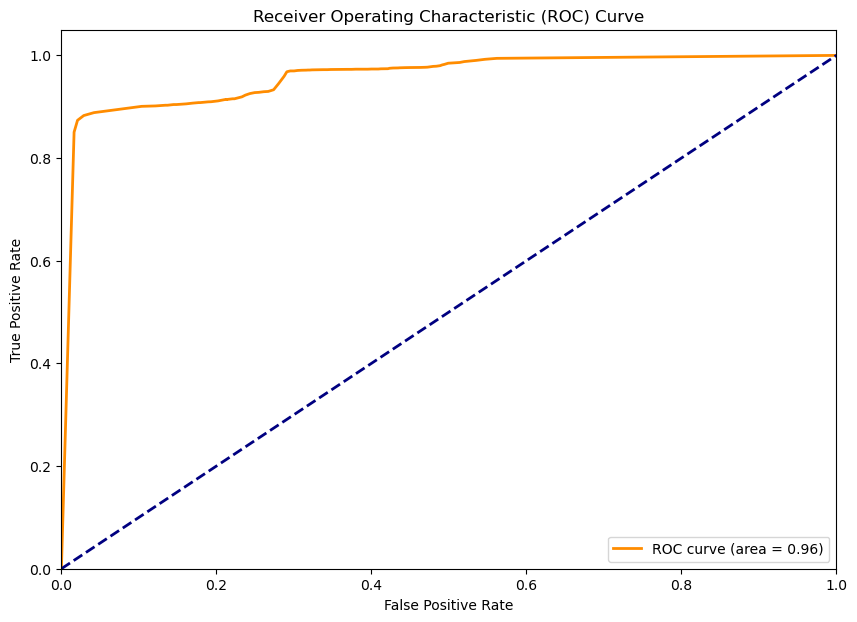

In [48]:
# --- NEW: AUC-ROC Calculation and Plotting ---
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

print(f"AUC Score: {roc_auc:.4f}")

# Plotting the ROC Curve
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Dashed line for random guess
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

In [49]:
thresholds

array([       inf, 1.        , 0.99      , 0.98      , 0.97      ,
       0.96      , 0.95      , 0.94      , 0.93      , 0.925     ,
       0.92      , 0.915     , 0.91      , 0.905     , 0.9       ,
       0.895     , 0.89      , 0.88166667, 0.88      , 0.87      ,
       0.865     , 0.86      , 0.855     , 0.85166667, 0.85      ,
       0.84      , 0.835     , 0.83333333, 0.83      , 0.825     ,
       0.82      , 0.815     , 0.81      , 0.8       , 0.79      ,
       0.78      , 0.77      , 0.765     , 0.76      , 0.755     ,
       0.75      , 0.74      , 0.73666667, 0.735     , 0.73      ,
       0.72666667, 0.725     , 0.72      , 0.71      , 0.7       ,
       0.6925    , 0.69      , 0.68      , 0.67      , 0.66      ,
       0.65      , 0.645     , 0.64      , 0.63      , 0.62      ,
       0.61      , 0.6       , 0.59      , 0.58      , 0.57      ,
       0.56      , 0.551     , 0.55      , 0.545     , 0.54      ,
       0.53      , 0.52711905, 0.52      , 0.5115    , 0.51   